In [29]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="r3ErAguz5nLW7XElnGIW")
project = rf.workspace("ball-detection-model").project("vehicle-detection-c2rly")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Vehicle-Detection-1 in yolov11:: 100%|██████████| 5886/5886 [00:00<00:00, 7575.23it/s]


In [30]:
!pip install ultralytics

In [31]:
import os
os.chdir("Vehicle-Detection-1")
print(os.listdir())

['data.yaml', 'train', 'README.dataset.txt', 'test', 'README.roboflow.txt', 'valid']


In [32]:
# !yolo task=detect mode=train model=yolov8n.pt data=data.yaml epochs=10 imgsz=640 batch=16 device=0

In [33]:
from ultralytics import YOLO
model = YOLO("yolov8m.pt")
model.train(
    data="data.yaml",
    epochs=35,
    imgsz=640, 
    batch=16,
    device=0
)

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=35, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=1

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e62d8456240>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     

In [34]:
!ls "/kaggle/working/Vehicle-Detection-1/Vehicle-Detection-1/runs/detect/train"

args.yaml			 results.csv	     val_batch0_labels.jpg
BoxF1_curve.png			 results.png	     val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg    val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1.jpg    val_batch1_pred.jpg
BoxR_curve.png			 train_batch2.jpg    val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch645.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch646.jpg  weights
labels.jpg			 train_batch647.jpg


In [35]:
!ls "/kaggle/working/Vehicle-Detection-1/Vehicle-Detection-1/runs/detect/train/weights"

best.pt  last.pt


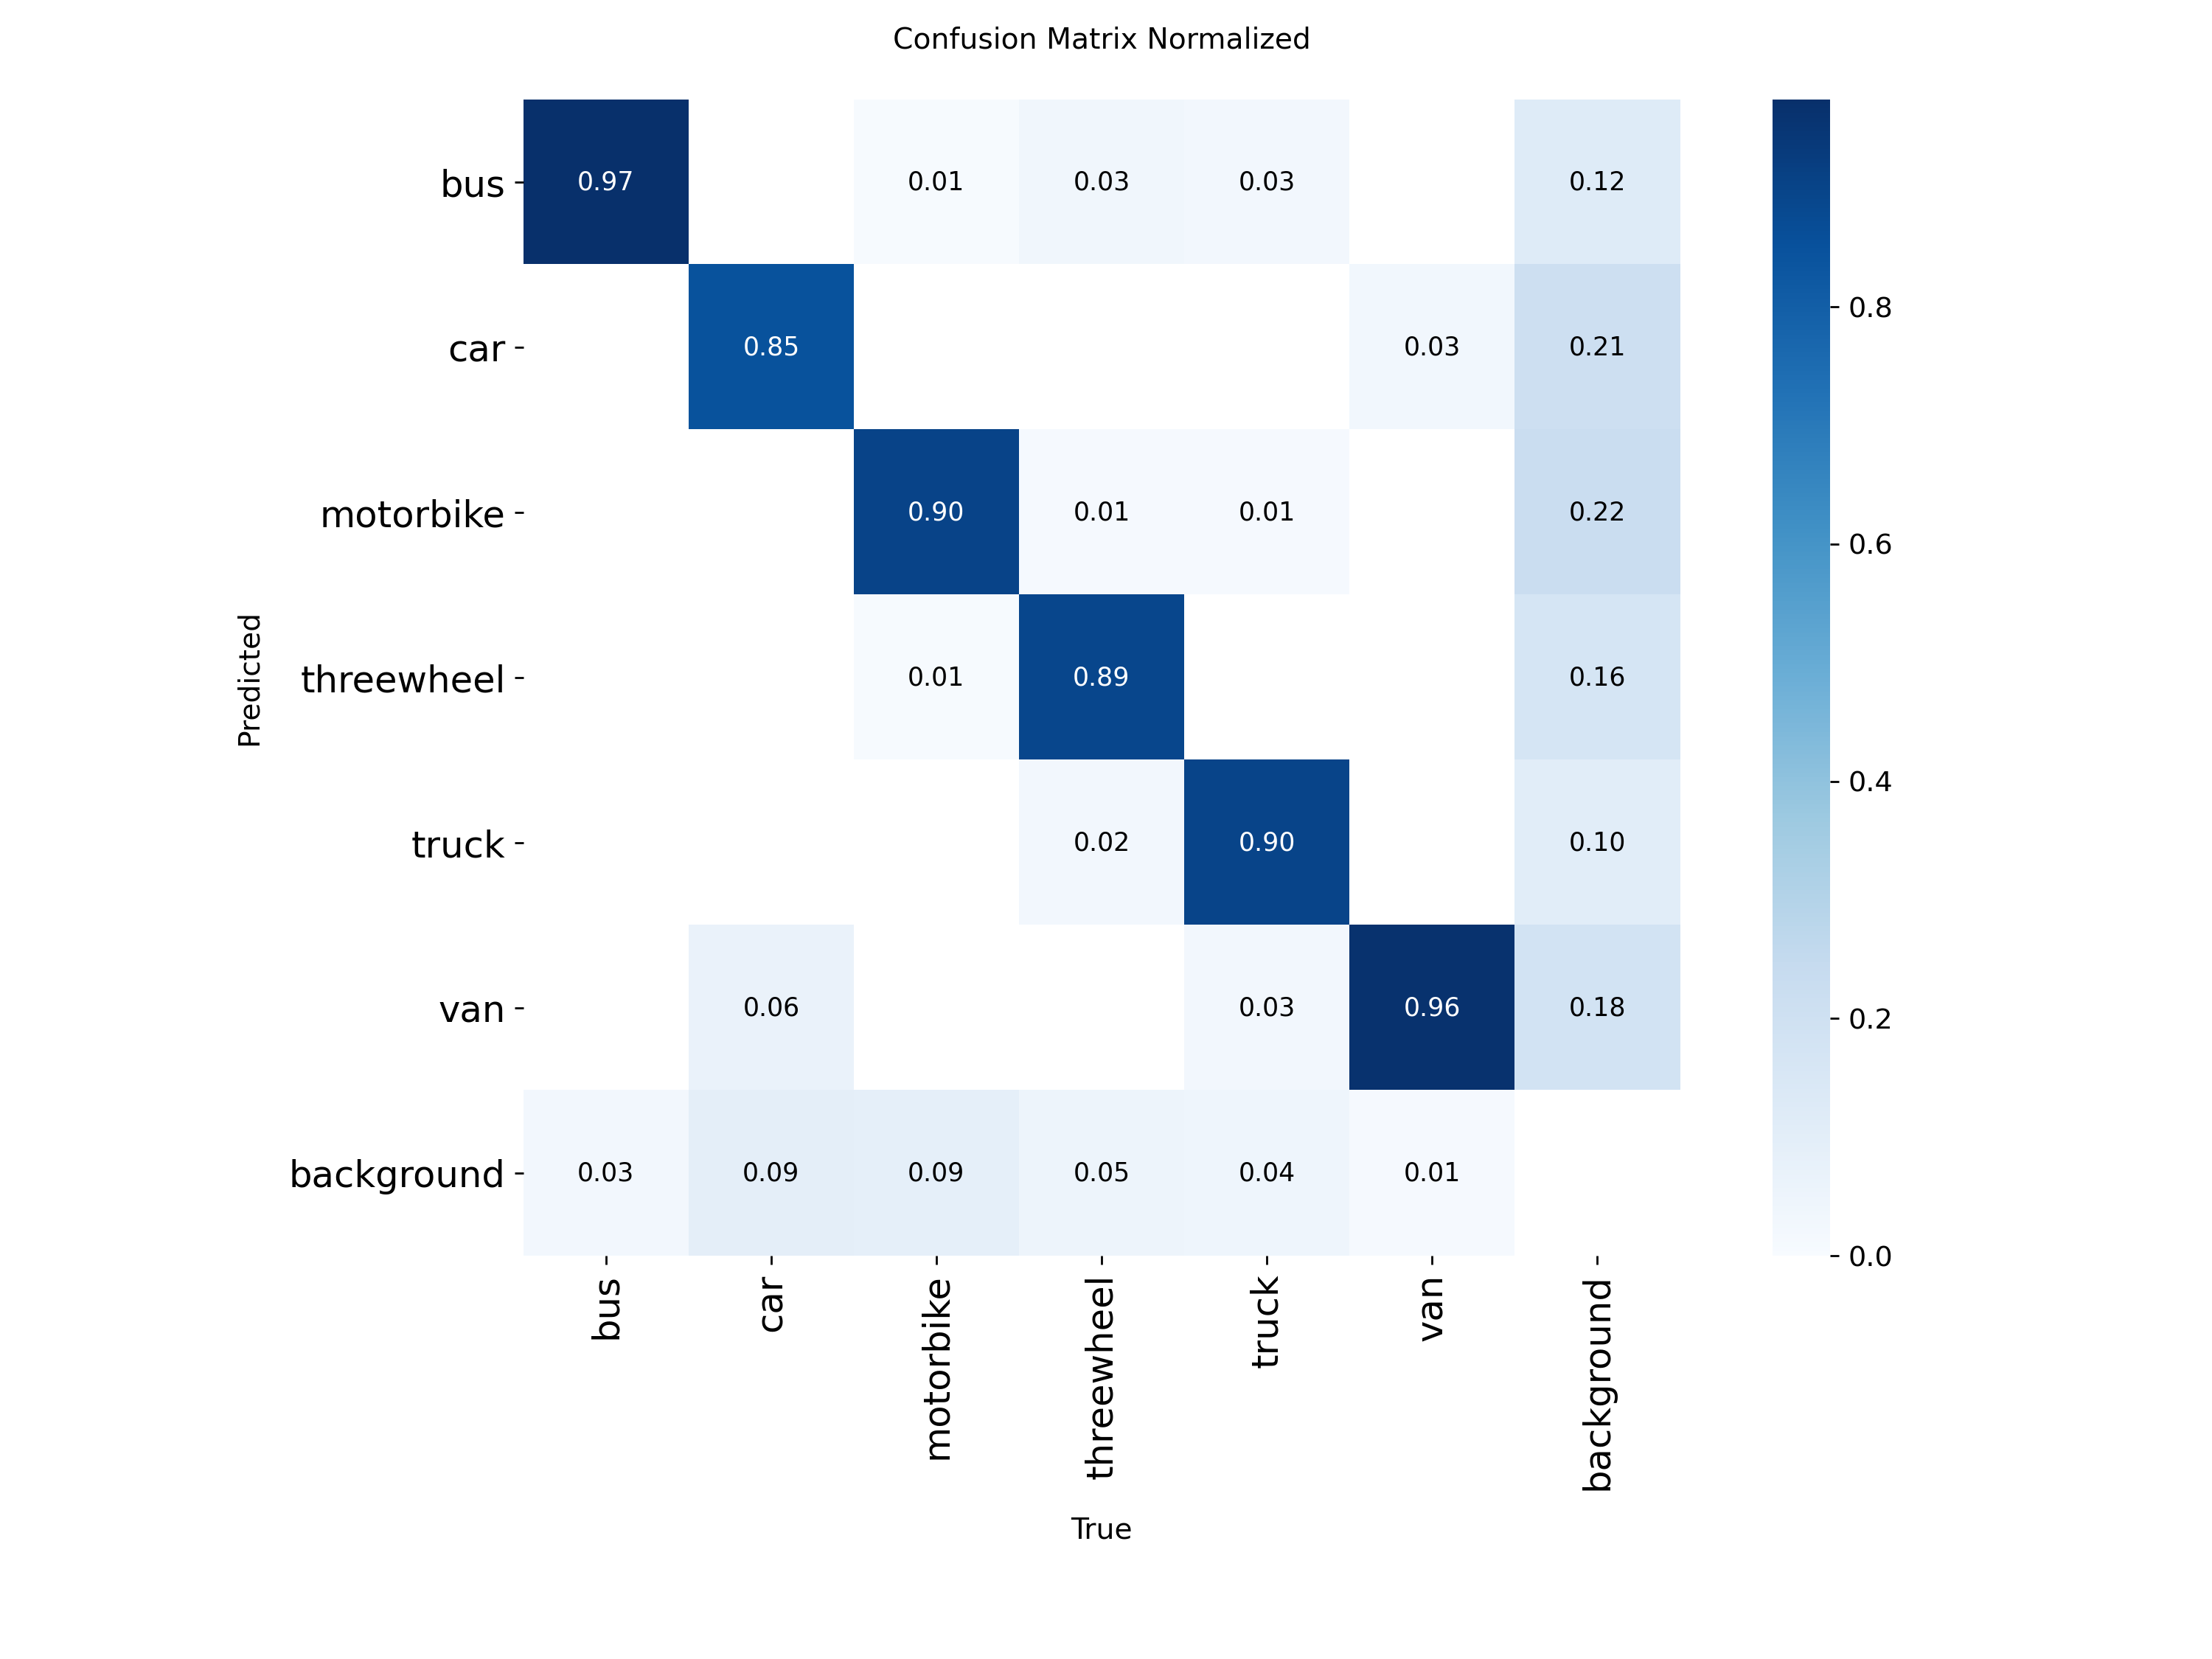

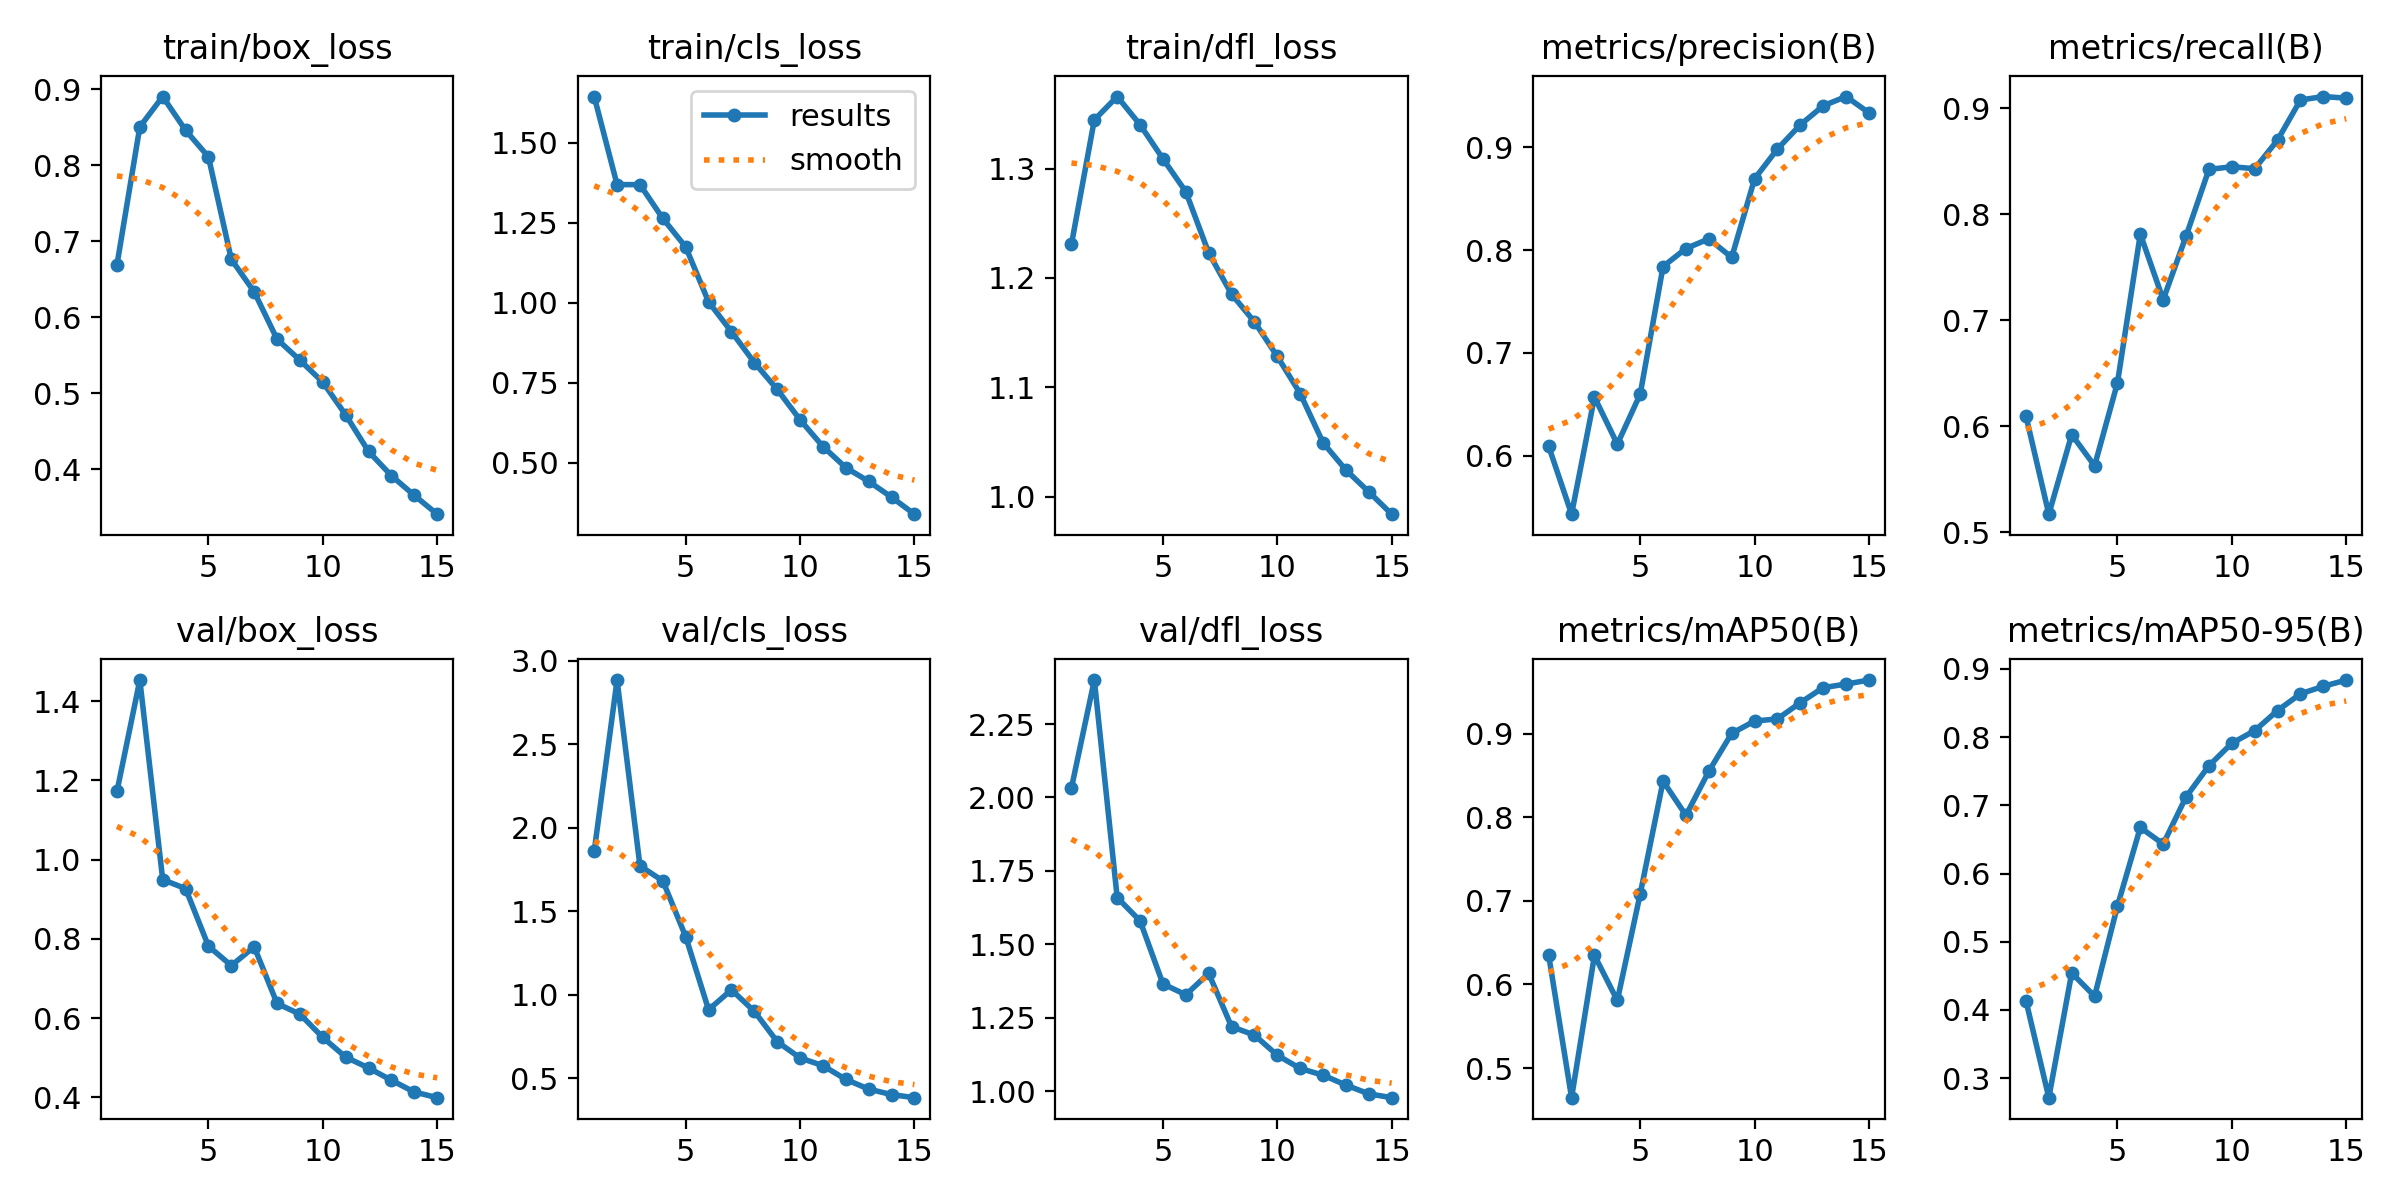

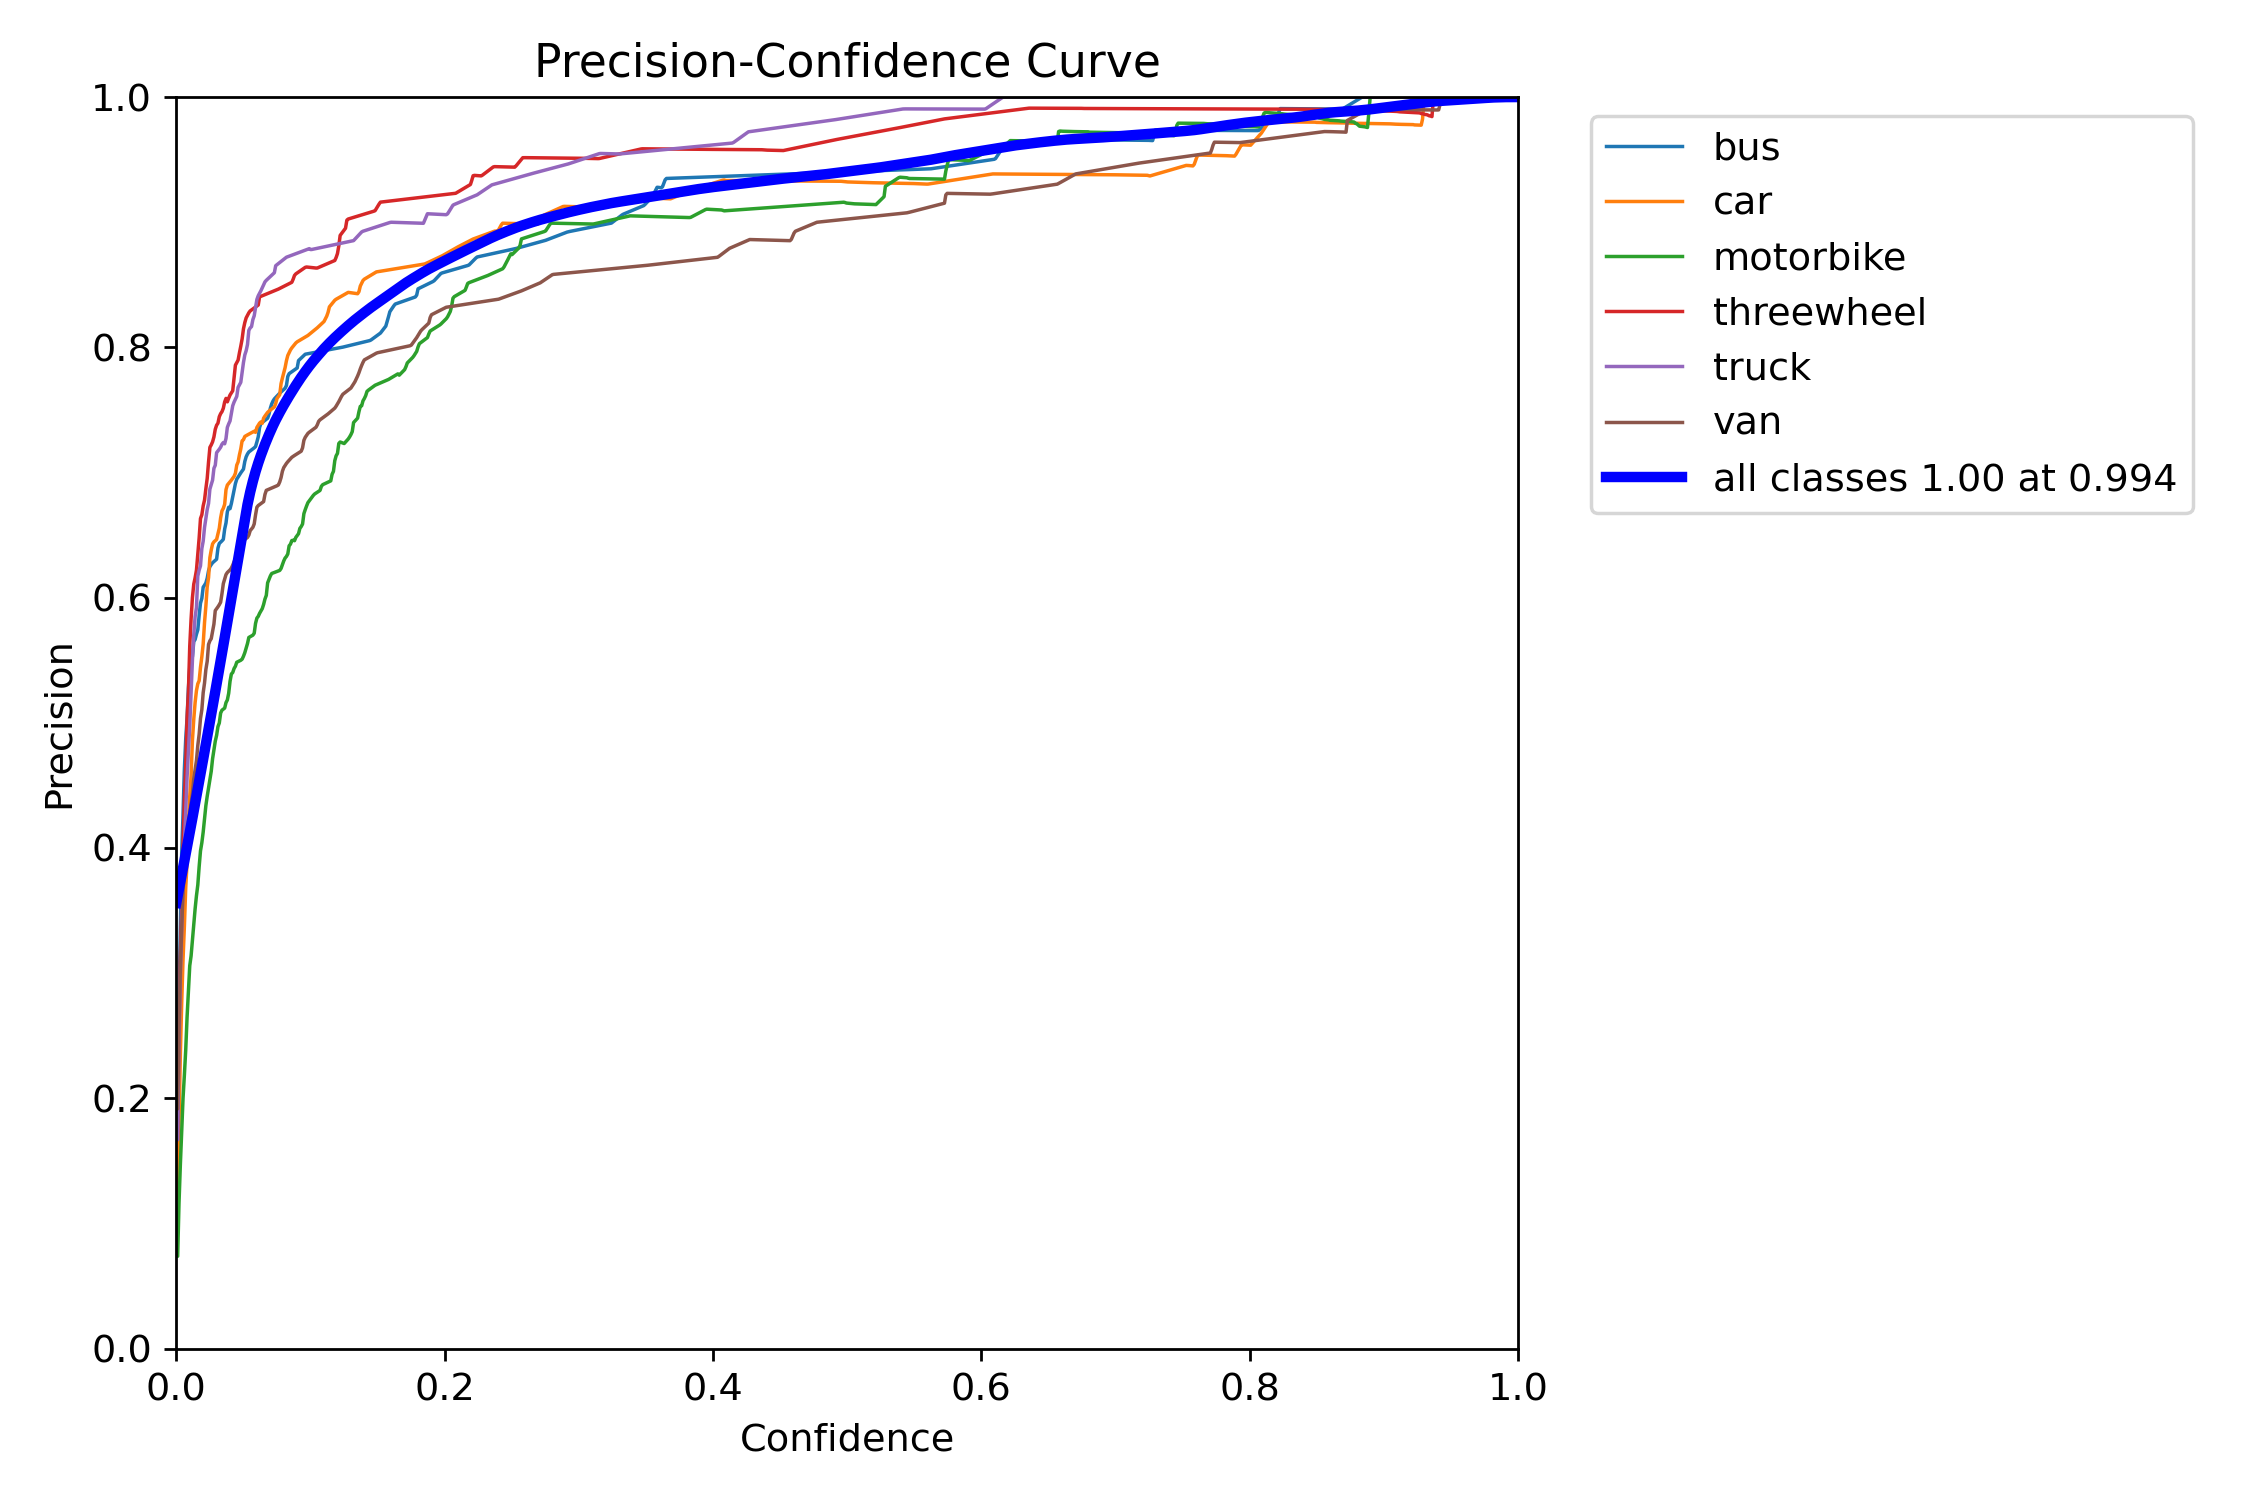

In [36]:
from IPython.display import Image, display

result_data = "/kaggle/working/Vehicle-Detection-1/Vehicle-Detection-1/runs/detect/train"
display(Image(filename=f"{result_data}/confusion_matrix_normalized.png", width=900))
display(Image(filename=f"{result_data}/results.png", width=800))
display(Image(filename = f"{result_data}/BoxP_curve.png", width=700))

In [ ]:
model.val(
    data="/kaggle/working/Vehicle-Detection-1/Vehicle-Detection-1/data.yaml",
    device=0
)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,843,234 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1012.2±261.2 MB/s, size: 67.0 KB)
val: Scanning /kaggle/working/Vehicle-Detection-1/valid/labels.cache... 592 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 592/592 108.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 37/37 2.4it/s 15.3s0.4s
                   all        592        742      0.954      0.924      0.969      0.904
                   bus        104        119      0.949      0.975      0.981      0.949
                   car        117        131      0.935       0.87       0.95      0.914
             motorbike        107        140      0.959      0.871       0.95      0.758
            threewheel         97        127      0.976      0.946      0.973      0.915
                 truck 

In [42]:
import pandas as pd

result_dir = "/kaggle/working/Vehicle-Detection-1/Vehicle-Detection-1/runs/detect/train"
df = pd.read_csv(f"{result_dir}/results.csv")

df.head()


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,75.710,0.66896,1.64443,1.23078,0.60907,0.60977,0.63481,0.41356,1.17185,1.85901,2.03271,0.000331,0.000331,0.000331
1,2,151.158,0.85074,1.36926,1.34458,0.54314,0.51708,0.46463,0.27137,1.45292,2.88561,2.39975,0.000620,0.000620,0.000620
2,3,225.730,0.89069,1.36931,1.36593,0.65712,0.59216,0.63481,0.45412,0.94930,1.77192,1.65911,0.000866,0.000866,0.000866
3,4,300.445,0.84624,1.26357,1.34015,0.61123,0.56274,0.58086,0.42011,0.92684,1.68217,1.58000,0.000802,0.000802,0.000802
4,5,374.846,0.81122,1.17461,1.30899,0.65990,0.64095,0.70818,0.55233,0.78155,1.34795,1.36531,0.000736,0.000736,0.000736


In [43]:
import pandas as pd

df = pd.read_csv("runs/detect/train/results.csv")

best_epoch = df["metrics/mAP50(B)"].idxmax()

P = df.loc[best_epoch, "metrics/precision(B)"]
R = df.loc[best_epoch, "metrics/recall(B)"]
F1 = 2 * P * R / (P + R)

P, R, F1


(np.float64(0.96147), np.float64(0.92276), np.float64(0.9417173669881066))

In [45]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/Vehicle-Detection-1/Vehicle-Detection-1/runs/detect/train/weights/best.pt")

# Memory-efficient video prediction and saving
results = model.predict(
    source="/kaggle/input/datasets/fazalullah21102/12-15-veheical-video/15_vehical_detection.mp4",
    conf=0.4,
    save=True,      # save annotated video
    stream=True     # memory-efficient for long videos
)

# Optional: inspect each frame's predictions
for r in results:
    print(r.boxes.xyxy)   # bounding box coordinates
    print(r.boxes.conf)   # confidence scores
    print(r.boxes.cls)    # class IDs



video 1/1 (frame 1/394) /kaggle/input/datasets/fazalullah21102/12-15-veheical-video/15_vehical_detection.mp4: 384x640 2 cars, 1 threewheel, 1 van, 25.9ms
tensor([[670.0737, 219.2653, 876.3736, 438.4852],
        [431.1046, 112.3558, 584.9207, 254.0314],
        [382.2239,  33.7940, 483.9564, 146.7460],
        [301.2356, 121.0248, 350.1402, 253.0947]], device='cuda:0')
tensor([0.8052, 0.7542, 0.7076, 0.4310], device='cuda:0')
tensor([5., 1., 1., 3.], device='cuda:0')
video 1/1 (frame 2/394) /kaggle/input/datasets/fazalullah21102/12-15-veheical-video/15_vehical_detection.mp4: 384x640 2 cars, 1 motorbike, 1 van, 25.0ms
tensor([[430.1194, 114.6476, 585.2778, 260.3139],
        [669.8128, 223.5208, 877.2424, 441.7700],
        [271.7714, 324.0534, 362.9520, 460.6907],
        [381.9053,  33.5621, 485.8376, 147.9639]], device='cuda:0')
tensor([0.8080, 0.7710, 0.5320, 0.5077], device='cuda:0')
tensor([1., 5., 2., 1.], device='cuda:0')
video 1/1 (frame 3/394) /kaggle/input/datasets/fazalulla

In [59]:
import pandas as pd

# Path to the results file
results_path = "/kaggle/working/Vehicle-Detection-1/Vehicle-Detection-1/Vehicle-Detection-1/runs/detect/train/results.csv"
df = pd.read_csv(results_path)

print(f"This model was trained for {len(df)} epochs.")

This model was trained for 35 epochs.
